# FASE 2 — Exploración y Entendimiento de Datos (EDA)
## K-Moda Marketing Mix Modeling · Trabajo IA (UAX)

**Input:** parquets limpios generados en la Fase 1.  
**Objetivo:** entender la estructura, distribución y dinámica de los datos antes de modelar.

| Bloque | Contenido |
|--------|-----------|
| A | Serie temporal de ventas — tendencia y estacionalidad |
| B | Estacionalidad: mes, día de semana, festivos |
| C | Distribución por ciudad, canal de venta y categoría |
| D | Inversión en medios — mix y evolución |
| E | Diagnóstico de privacidad (GDPR / iOS 14) |
| F | Correlaciones preliminares adstock × ventas |

In [1]:
# ============================================================
# CELDA 1 — IMPORTS Y CONFIGURACIÓN
# ============================================================
import os
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')

# Paleta corporativa K-Moda
GOLD    = '#C9A84C'
BLACK   = '#1A1A1A'
CREAM   = '#F5F0E8'
DARK    = '#2C2C2C'
GRAY    = '#8C8C8C'
RED_    = '#C0392B'
GREEN_  = '#27AE60'
BLUE_   = '#2980B9'
TEAL_   = '#16A085'
ORANGE_ = '#E67E22'
PURPLE_ = '#8E44AD'

COLORS = [
    GOLD, '#5B4A2E', '#8B7355', '#D4B896',
    '#A0856C', '#E8D5B7', '#6B5344', '#9B8B77',
    '#C4A882', '#7A6654',
]

plt.rcParams.update({
    'figure.facecolor' : CREAM,
    'axes.facecolor'   : CREAM,
    'axes.edgecolor'   : BLACK,
    'axes.labelcolor'  : BLACK,
    'xtick.color'      : BLACK,
    'ytick.color'      : BLACK,
    'text.color'       : BLACK,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'legend.fontsize'  : 10,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

PROJECT_DIR = os.path.dirname(os.path.abspath('02_eda.ipynb'))
IMG_DIR     = os.path.join(PROJECT_DIR, 'img')
DATA_DIR_CSV= os.path.join(PROJECT_DIR, 'CASOMAT_MM_07_VENTAS_LINEAS')
os.makedirs(IMG_DIR, exist_ok=True)

def guardar_img(nombre, fig=None, dpi=150):
    pattern = re.compile(rf'^{re.escape(nombre)}_v(\d+)\.png$')
    existing = [int(m.group(1)) for f in os.listdir(IMG_DIR) if (m := pattern.match(f))]
    v = max(existing) + 1 if existing else 1
    ruta = os.path.join(IMG_DIR, f'{nombre}_v{v:03d}.png')
    (fig or plt.gcf()).savefig(ruta, dpi=dpi, bbox_inches='tight', facecolor=CREAM)
    print(f'  → img/{nombre}_v{v:03d}.png')
    return ruta

print('✓ Setup listo')

✓ Setup listo


In [2]:
# ============================================================
# CELDA 2 — CARGA DE DATOS (parquets Fase 1 + CSVs originales)
# ============================================================
df_ventas = pd.read_parquet(os.path.join(PROJECT_DIR, 'data', 'df_ventas_clean.parquet'))
df_inv    = pd.read_parquet(os.path.join(PROJECT_DIR, 'data', 'df_inversion_clean.parquet'))

# CSV originales para análisis de dimensiones
ventas_lineas = pd.read_csv(os.path.join(DATA_DIR_CSV, 'CASOMAT_MM_07_VENTAS_LINEAS.csv'),
                            parse_dates=['fecha_venta'])
inv_medios    = pd.read_csv(os.path.join(DATA_DIR_CSV, 'CASOMAT_MM_05_INVERSION_MEDIOS.csv'),
                            parse_dates=['semana_inicio', 'semana_fin'])

# Columnas auxiliares
ventas_lineas['anio'] = ventas_lineas['fecha_venta'].dt.year
ventas_lineas['mes']  = ventas_lineas['fecha_venta'].dt.month
ventas_lineas['dow']  = ventas_lineas['fecha_venta'].dt.dayofweek  # 0=Lunes
inv_medios['anio']    = inv_medios['semana_inicio'].dt.year

CANALES_MEDIOS = sorted(inv_medios['canal_medio'].unique().tolist())

print(f'✓ df_ventas : {df_ventas.shape}  |  semanas: {len(df_ventas)}')
print(f'✓ df_inv    : {df_inv.shape}  |  canales: {len(CANALES_MEDIOS)}')
print(f'✓ ventas_lineas : {len(ventas_lineas):,} filas')
print(f'  Período: {df_ventas["semana_dt"].min().date()} → {df_ventas["semana_dt"].max().date()}')

✓ df_ventas : (261, 19)  |  semanas: 261
✓ df_inv    : (261, 10)  |  canales: 8
✓ ventas_lineas : 8,000,000 filas
  Período: 2020-01-06 → 2024-12-30


---
## Bloque A — Serie Temporal de Ventas

  → img/serie_temporal_ventas_v007.png


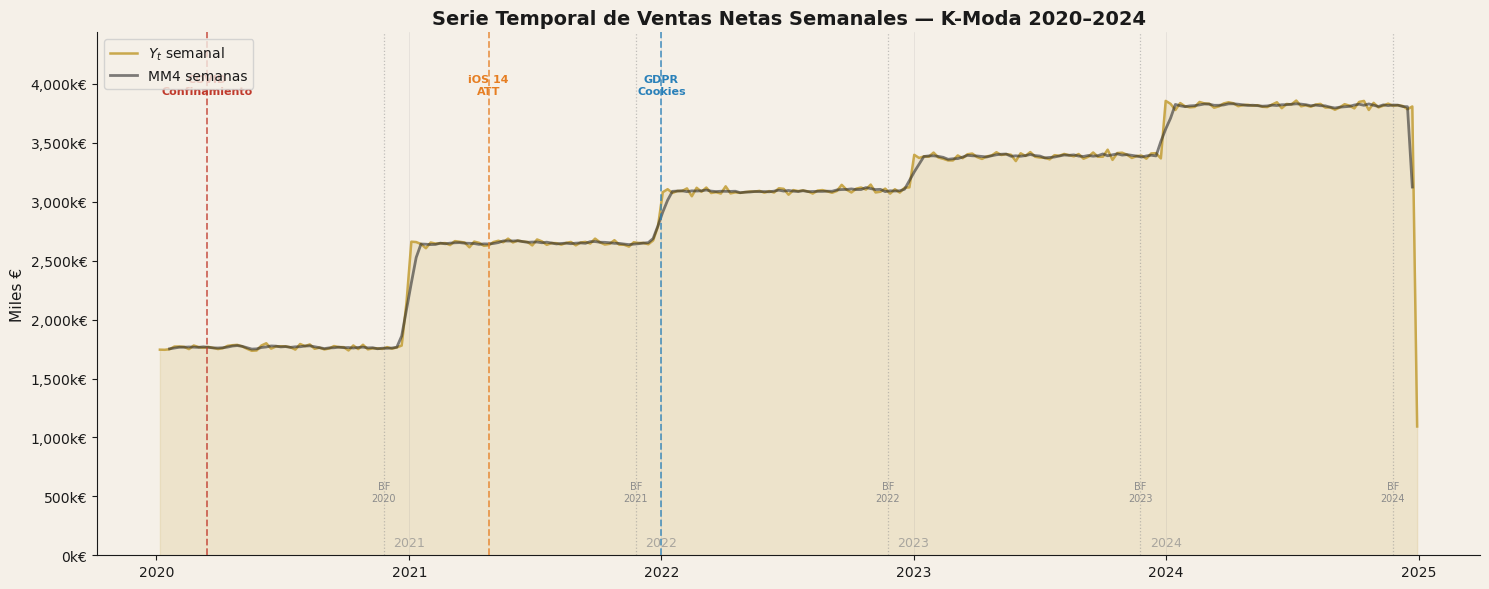

In [3]:
# ============================================================
# GRÁFICA A1 — Serie temporal Yt semanal con eventos clave
# ============================================================
fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor(CREAM)

ax.plot(df_ventas['semana_dt'], df_ventas['Yt'] / 1e3,
        color=GOLD, linewidth=1.8, zorder=3, label='$Y_t$ semanal')
ax.fill_between(df_ventas['semana_dt'], df_ventas['Yt'] / 1e3,
                alpha=0.18, color=GOLD, zorder=2)

# Media móvil 4 semanas
mm4 = df_ventas['Yt'].rolling(4, center=True).mean()
ax.plot(df_ventas['semana_dt'], mm4 / 1e3,
        color=DARK, linewidth=2, linestyle='-', alpha=0.6, zorder=4, label='MM4 semanas')

# Eventos clave
eventos = [
    ('2020-03-14', 'COVID\nConfinamiento', RED_),
    ('2021-04-26', 'iOS 14\nATT', ORANGE_),
    ('2022-01-01', 'GDPR\nCookies', BLUE_),
]
y_max = df_ventas['Yt'].max() / 1e3
for fecha_str, label, color in eventos:
    ax.axvline(pd.Timestamp(fecha_str), color=color, linestyle='--',
               alpha=0.75, linewidth=1.3, zorder=5)
    ax.text(pd.Timestamp(fecha_str), y_max * 1.01, label,
            fontsize=8, color=color, ha='center', va='bottom', fontweight='bold')

# Black Fridays
for yr in range(2020, 2025):
    bf = pd.Timestamp(f'{yr}-11-25')
    ax.axvline(bf, color=GRAY, linestyle=':', alpha=0.5, linewidth=0.9)
    ax.text(bf, y_max * 0.12, f'BF\n{yr}', fontsize=7, color=GRAY, ha='center')

# Separadores de año
for yr in range(2021, 2025):
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color=GRAY, linestyle='-', alpha=0.2, linewidth=0.5)
    ax.text(pd.Timestamp(f'{yr}-01-01'), y_max * 0.02, str(yr),
            fontsize=9, color=GRAY, ha='center', alpha=0.7)

ax.set_title('Serie Temporal de Ventas Netas Semanales — K-Moda 2020–2024',
             fontweight='bold', fontsize=14)
ax.set_ylabel('Miles €')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}k€'))
ax.legend(loc='upper left')
ax.set_ylim(0, y_max * 1.15)

plt.tight_layout()
guardar_img('serie_temporal_ventas', fig)
plt.show()

  → img/eda_ventas_mensuales_v007.png


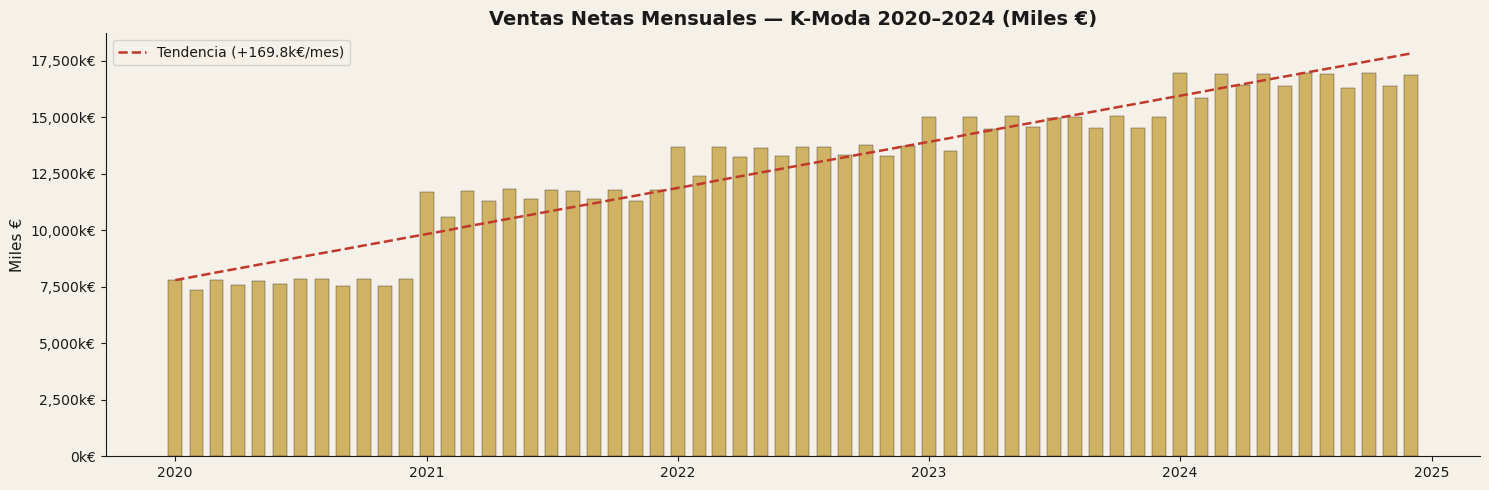

In [4]:
# ============================================================
# GRÁFICA A2 — Ventas mensuales: serie temporal 2020–2024
# ============================================================
ventas_mensual = (
    ventas_lineas
    .groupby(ventas_lineas['fecha_venta'].dt.to_period('M'))['venta_neta_sin_iva_eur']
    .sum()
)
ventas_mensual.index = ventas_mensual.index.to_timestamp()

fig, ax = plt.subplots(figsize=(15, 5))
fig.patch.set_facecolor(CREAM)

ax.bar(ventas_mensual.index, ventas_mensual.values / 1e3,
       width=20, color=GOLD, edgecolor=BLACK, linewidth=0.3, alpha=0.85)

# Línea de tendencia
x_num = np.arange(len(ventas_mensual))
z = np.polyfit(x_num, ventas_mensual.values / 1e3, 1)
p = np.poly1d(z)
ax.plot(ventas_mensual.index, p(x_num), color=RED_, linewidth=1.8,
        linestyle='--', label=f'Tendencia ({z[0]:+.1f}k€/mes)')

ax.set_title('Ventas Netas Mensuales — K-Moda 2020–2024 (Miles €)',
             fontweight='bold', fontsize=14)
ax.set_ylabel('Miles €')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}k€'))
ax.legend()

plt.tight_layout()
guardar_img('eda_ventas_mensuales', fig)
plt.show()

  → img/eda_ventas_anuales_v007.png


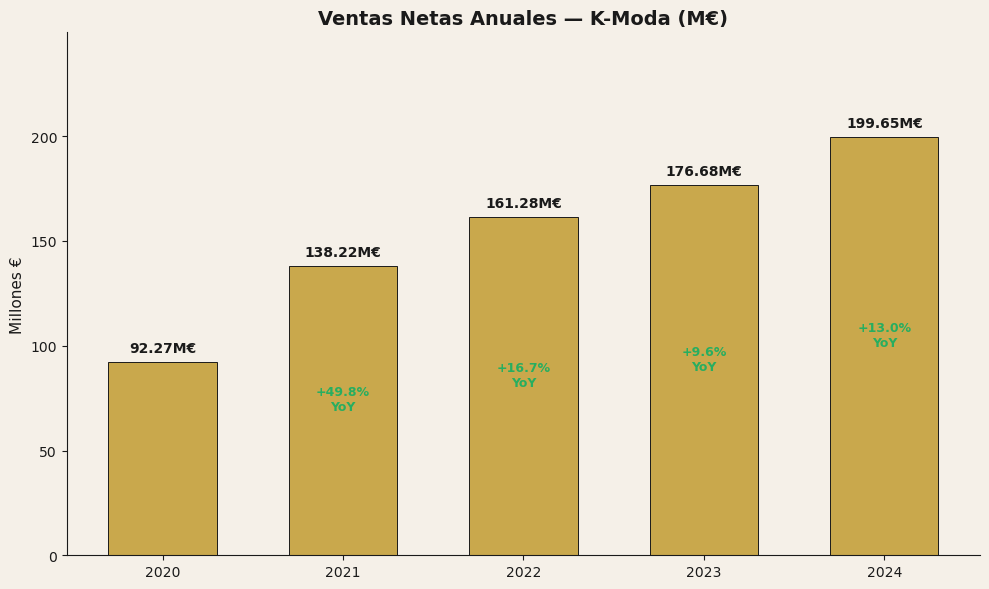

In [5]:
# ============================================================
# GRÁFICA A3 — Ventas anuales: barras con variación YoY
# ============================================================
ventas_anio = ventas_lineas.groupby('anio')['venta_neta_sin_iva_eur'].sum()

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(CREAM)

colores_barras = [GOLD] * len(ventas_anio)
bars = ax.bar(ventas_anio.index, ventas_anio.values / 1e6,
              color=colores_barras, edgecolor=BLACK, linewidth=0.7, width=0.6)
ax.bar_label(bars, fmt='%.2fM€', padding=5, fontsize=10, fontweight='bold')

# Variación YoY
for i, (anio, val) in enumerate(ventas_anio.items()):
    if i > 0:
        prev = ventas_anio.iloc[i - 1]
        yoy = (val - prev) / prev * 100
        color_yoy = GREEN_ if yoy >= 0 else RED_
        ax.text(anio, val / 1e6 * 0.5, f'{yoy:+.1f}%\nYoY',
                ha='center', fontsize=9, color=color_yoy, fontweight='bold')

ax.set_title('Ventas Netas Anuales — K-Moda (M€)', fontweight='bold', fontsize=14)
ax.set_ylabel('Millones €')
ax.set_ylim(0, ventas_anio.max() / 1e6 * 1.25)

plt.tight_layout()
guardar_img('eda_ventas_anuales', fig)
plt.show()

---
## Bloque B — Estacionalidad

  → img/eda_estacionalidad_mensual_v007.png


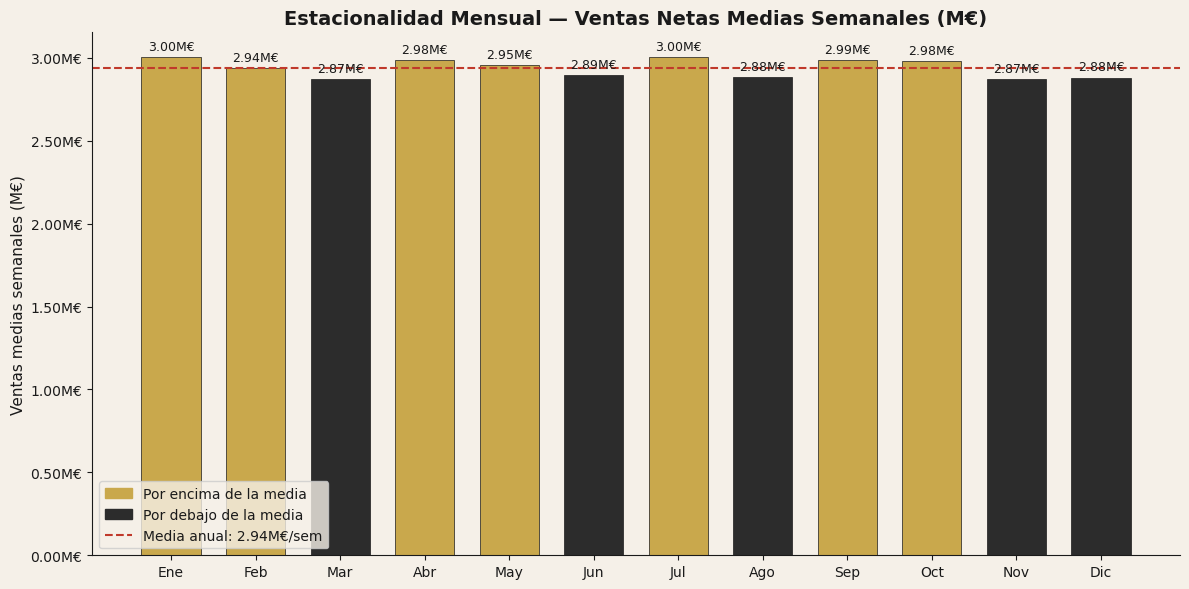

In [6]:
# ============================================================
# GRÁFICA B1 — Estacionalidad mensual (venta media semanal Yt)
# ============================================================
# Agrupamos df_ventas (nivel semanal nacional) por mes.
# Usar ventas_lineas.mean() daría el ticket medio de cada línea (~96€ uniforme)
# en lugar de mostrar la estacionalidad real del volumen de ventas.
df_ventas['mes'] = pd.to_datetime(df_ventas['semana_dt']).dt.month
ventas_mes = df_ventas.groupby('mes')['Yt'].mean()
meses_labels = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
media_global = ventas_mes.mean()

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(CREAM)

colores_mes = [GOLD if v >= media_global else DARK for v in ventas_mes.values]
bars = ax.bar(range(1, 13), ventas_mes.values / 1e6,
              color=colores_mes, edgecolor=BLACK, linewidth=0.5, width=0.7)
ax.bar_label(bars, labels=[f'{v/1e6:.2f}M€' for v in ventas_mes.values],
             padding=3, fontsize=9)
ax.axhline(media_global / 1e6, color=RED_, linestyle='--', linewidth=1.5,
           label=f'Media anual: {media_global/1e6:.2f}M€/sem')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_labels)
ax.set_title('Estacionalidad Mensual — Ventas Netas Medias Semanales (M€)',
             fontweight='bold', fontsize=14)
ax.set_ylabel('Ventas medias semanales (M€)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}M€'))

gold_patch = mpatches.Patch(color=GOLD, label='Por encima de la media')
dark_patch = mpatches.Patch(color=DARK, label='Por debajo de la media')
ax.legend(handles=[gold_patch, dark_patch, ax.get_lines()[0]])

plt.tight_layout()
guardar_img('eda_estacionalidad_mensual', fig)
plt.show()

  → img/eda_heatmap_estacional_v007.png


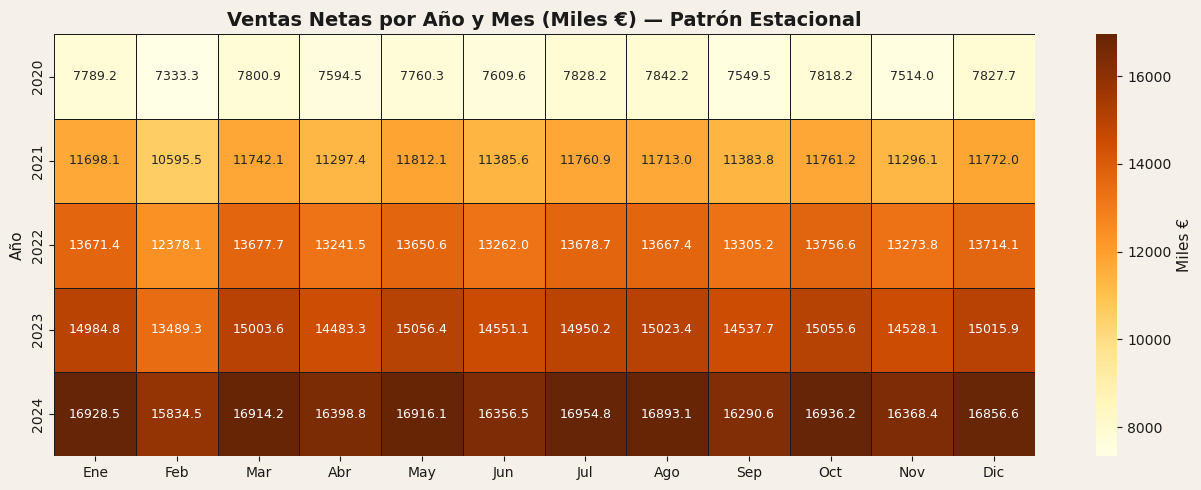

In [7]:
# ============================================================
# GRÁFICA B2 — Estacionalidad mensual por año (heatmap)
# ============================================================
ventas_mes_anio = (
    ventas_lineas
    .groupby(['anio', 'mes'])['venta_neta_sin_iva_eur']
    .sum()
    .unstack(level='mes')
)
ventas_mes_anio.columns = meses_labels

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(CREAM)

sns.heatmap(
    ventas_mes_anio / 1e3, ax=ax,
    cmap='YlOrBr', annot=True, fmt='.1f',
    annot_kws={'size': 9}, linewidths=0.5, linecolor=BLACK,
    cbar_kws={'label': 'Miles €'}
)
ax.set_title('Ventas Netas por Año y Mes (Miles €) — Patrón Estacional',
             fontweight='bold', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Año')

plt.tight_layout()
guardar_img('eda_heatmap_estacional', fig)
plt.show()

  → img/eda_distribucion_pvp_v005.png


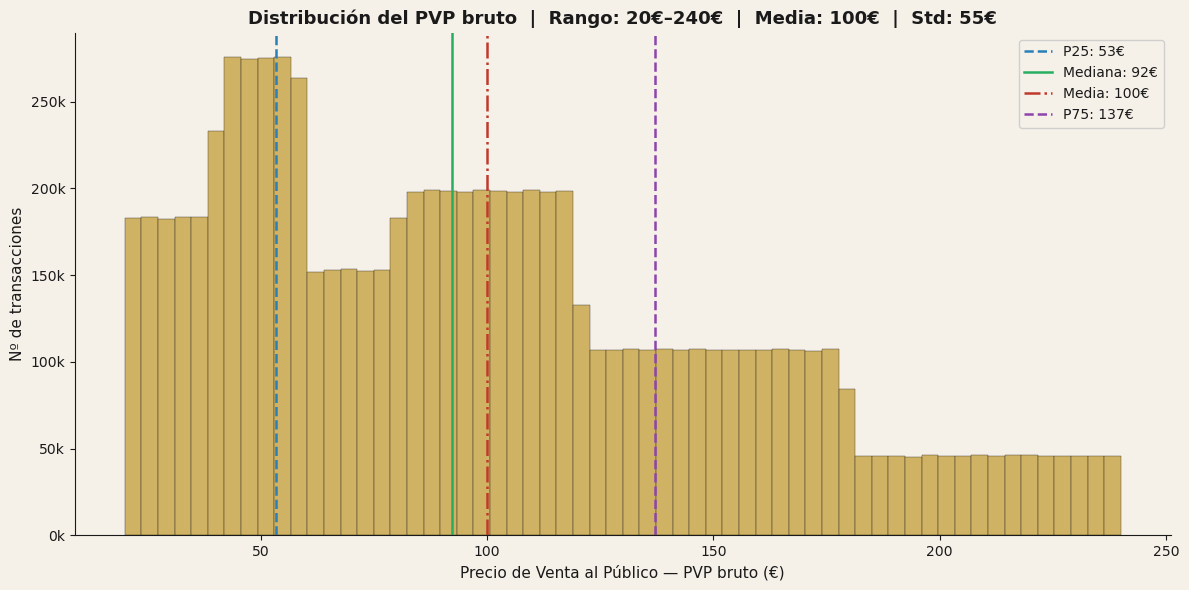

In [8]:
# ============================================================
# GRÁFICA B3 — Distribución del Precio de Venta (PVP bruto)
# ============================================================
# El dataset sintético distribuye transacciones uniformemente entre
# los 7 días de la semana (variación <0.1%). En su lugar mostramos
# la distribución de precios, que sí tiene variación real (20–240€).
pvp = ventas_lineas['pvp_bruto_eur']
p25, p50, p75 = pvp.quantile([0.25, 0.50, 0.75])
media_pvp = pvp.mean()

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(CREAM)

ax.hist(pvp, bins=60, color=GOLD, edgecolor=BLACK, linewidth=0.3, alpha=0.85)

for val, label, color, ls in [
    (p25,       f'P25: {p25:.0f}€',        BLUE_,   '--'),
    (p50,       f'Mediana: {p50:.0f}€',    GREEN_,  '-'),
    (media_pvp, f'Media: {media_pvp:.0f}€', RED_,   '-.'),
    (p75,       f'P75: {p75:.0f}€',        PURPLE_, '--'),
]:
    ax.axvline(val, color=color, linestyle=ls, linewidth=1.8, label=label)

ax.set_xlabel('Precio de Venta al Público — PVP bruto (€)', fontsize=11)
ax.set_ylabel('Nº de transacciones', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.set_title(
    f'Distribución del PVP bruto'
    f'  |  Rango: {pvp.min():.0f}€–{pvp.max():.0f}€'
    f'  |  Media: {media_pvp:.0f}€  |  Std: {pvp.std():.0f}€',
    fontweight='bold', fontsize=13)
ax.legend(fontsize=10, framealpha=0.9)

plt.tight_layout()
guardar_img('eda_distribucion_pvp', fig)
plt.show()

  → img/eda_efecto_calendario_v007.png


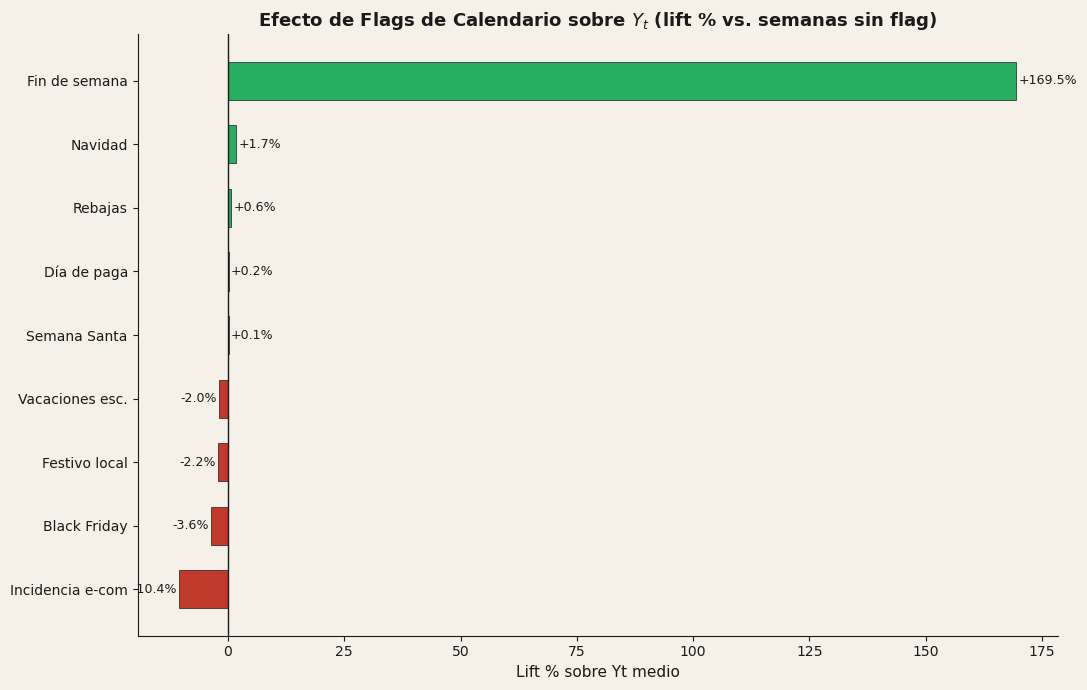

In [9]:
# ============================================================
# GRÁFICA B4 — Efecto de los flags de calendario sobre Yt
# ============================================================
FLAG_COLS = [
    'payday_flag', 'rebajas_flag', 'black_friday_flag', 'navidad_flag',
    'semana_santa_flag', 'vacaciones_escolares_flag', 'festivo_local_flag',
    'fin_de_semana', 'incidencia_ecommerce_flag',
]
FLAG_LABELS = {
    'payday_flag'              : 'Día de paga',
    'rebajas_flag'             : 'Rebajas',
    'black_friday_flag'        : 'Black Friday',
    'navidad_flag'             : 'Navidad',
    'semana_santa_flag'        : 'Semana Santa',
    'vacaciones_escolares_flag': 'Vacaciones esc.',
    'festivo_local_flag'       : 'Festivo local',
    'fin_de_semana'            : 'Fin de semana',
    'incidencia_ecommerce_flag': 'Incidencia e-com',
}

efectos = []
yt_base = df_ventas['Yt'].mean()
for flag in FLAG_COLS:
    mean_on  = df_ventas[df_ventas[flag] == 1]['Yt'].mean()
    mean_off = df_ventas[df_ventas[flag] == 0]['Yt'].mean()
    lift_pct = (mean_on - mean_off) / mean_off * 100
    efectos.append({'flag': FLAG_LABELS[flag], 'lift_pct': lift_pct,
                    'mean_on': mean_on, 'mean_off': mean_off})

ef_df = pd.DataFrame(efectos).sort_values('lift_pct')

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(CREAM)

colores_ef = [GREEN_ if v >= 0 else RED_ for v in ef_df['lift_pct']]
bars = ax.barh(ef_df['flag'], ef_df['lift_pct'],
               color=colores_ef, edgecolor=BLACK, linewidth=0.5, height=0.6)
ax.axvline(0, color=BLACK, linewidth=1)
for bar, v in zip(bars, ef_df['lift_pct']):
    x_pos = v + 0.5 if v >= 0 else v - 0.5
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{v:+.1f}%', va='center', ha='left' if v >= 0 else 'right', fontsize=9)

ax.set_title('Efecto de Flags de Calendario sobre $Y_t$ (lift % vs. semanas sin flag)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Lift % sobre Yt medio')

plt.tight_layout()
guardar_img('eda_efecto_calendario', fig)
plt.show()

---
## Bloque C — Distribución por Ciudad, Canal y Categoría

  → img/eda_ventas_ciudad_v007.png


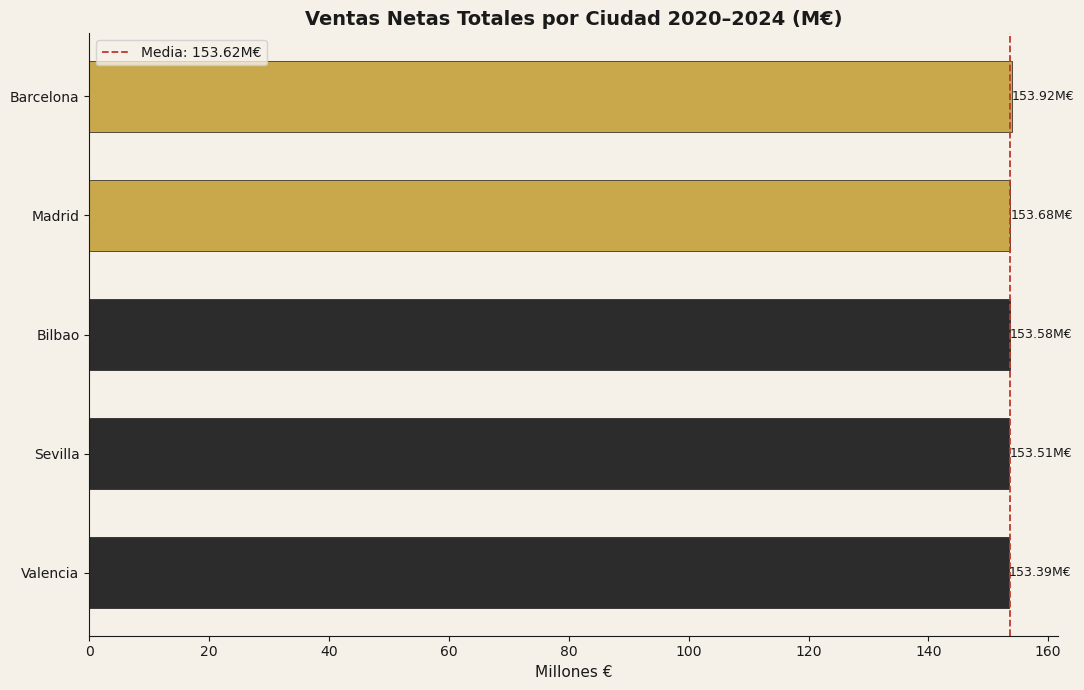

In [10]:
# ============================================================
# GRÁFICA C1 — Ventas por ciudad (barras horizontales)
# ============================================================
ventas_ciudad = (
    ventas_lineas
    .groupby('ciudad')['venta_neta_sin_iva_eur']
    .sum()
    .sort_values(ascending=True)
)
media_ciudad = ventas_ciudad.mean()

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(CREAM)

colores_c = [GOLD if v >= media_ciudad else DARK for v in ventas_ciudad.values]
bars = ax.barh(ventas_ciudad.index, ventas_ciudad.values / 1e6,
               color=colores_c, edgecolor=BLACK, linewidth=0.5, height=0.6)
for bar, v in zip(bars, ventas_ciudad.values):
    ax.text(v / 1e6 + 0.005, bar.get_y() + bar.get_height()/2,
            f'{v/1e6:.2f}M€', va='center', fontsize=9)
ax.axvline(media_ciudad / 1e6, color=RED_, linestyle='--', linewidth=1.3,
           label=f'Media: {media_ciudad/1e6:.2f}M€')
ax.set_title('Ventas Netas Totales por Ciudad 2020–2024 (M€)',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Millones €')
ax.legend()

plt.tight_layout()
guardar_img('eda_ventas_ciudad', fig)
plt.show()

  → img/eda_cuota_ciudad_v007.png


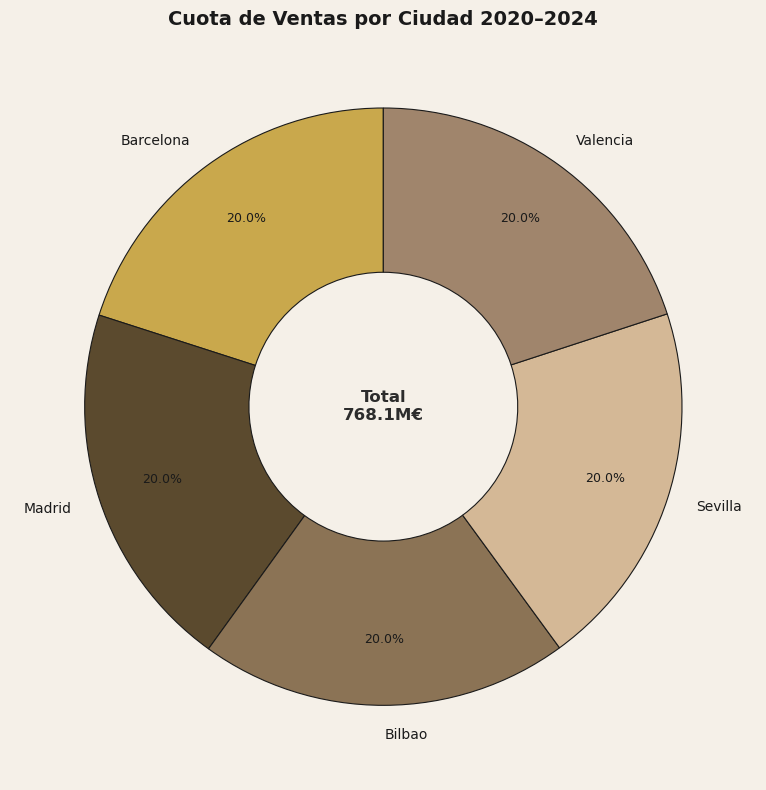

In [11]:
# ============================================================
# GRÁFICA C2 — Cuota de ventas por ciudad (donut)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(CREAM)

vc_sorted = ventas_ciudad.sort_values(ascending=False)
wedges, texts, autotexts = ax.pie(
    vc_sorted.values,
    labels=vc_sorted.index,
    autopct='%1.1f%%',
    colors=COLORS[:len(vc_sorted)],
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(edgecolor=BLACK, linewidth=0.8, width=0.55),
)
for at in autotexts:
    at.set_fontsize(9)
for t in texts:
    t.set_fontsize(10)

ax.text(0, 0, f'Total\n{ventas_ciudad.sum()/1e6:.1f}M€',
        ha='center', va='center', fontsize=12, fontweight='bold', color=DARK)
ax.set_title('Cuota de Ventas por Ciudad 2020–2024', fontweight='bold', fontsize=14)

plt.tight_layout()
guardar_img('eda_cuota_ciudad', fig)
plt.show()

  → img/eda_ventas_canal_venta_v007.png


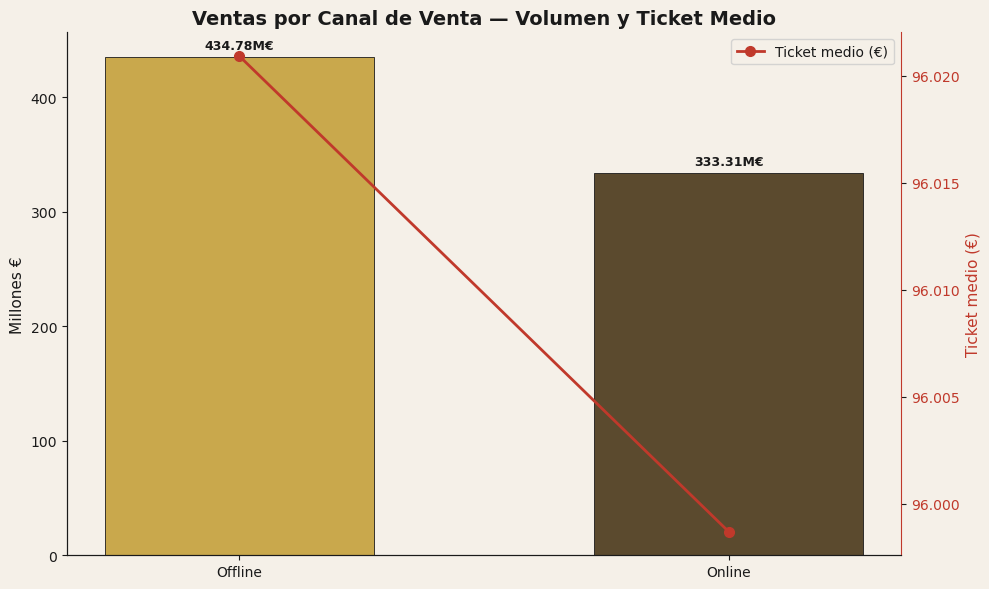

In [12]:
# ============================================================
# GRÁFICA C3 — Ventas por canal de venta
# ============================================================
ventas_canal = (
    ventas_lineas
    .groupby('canal_venta')['venta_neta_sin_iva_eur']
    .agg(['sum', 'count', 'mean'])
    .sort_values('sum', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(CREAM)

bars = ax.bar(ventas_canal.index, ventas_canal['sum'] / 1e6,
              color=COLORS[:len(ventas_canal)], edgecolor=BLACK, linewidth=0.6, width=0.55)
ax.bar_label(bars, labels=[f'{v/1e6:.2f}M€' for v in ventas_canal['sum']],
             padding=4, fontsize=9, fontweight='bold')

# Ticket medio como línea secundaria
ax2 = ax.twinx()
ax2.plot(ventas_canal.index, ventas_canal['mean'],
         color=RED_, linewidth=2, marker='o', markersize=7, label='Ticket medio (€)')
ax2.set_ylabel('Ticket medio (€)', color=RED_)
ax2.tick_params(axis='y', labelcolor=RED_)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color(RED_)

ax.set_title('Ventas por Canal de Venta — Volumen y Ticket Medio',
             fontweight='bold', fontsize=14)
ax.set_ylabel('Millones €')
ax2.legend(loc='upper right')

plt.tight_layout()
guardar_img('eda_ventas_canal_venta', fig)
plt.show()

  → img/eda_ventas_canal_anio_v006.png


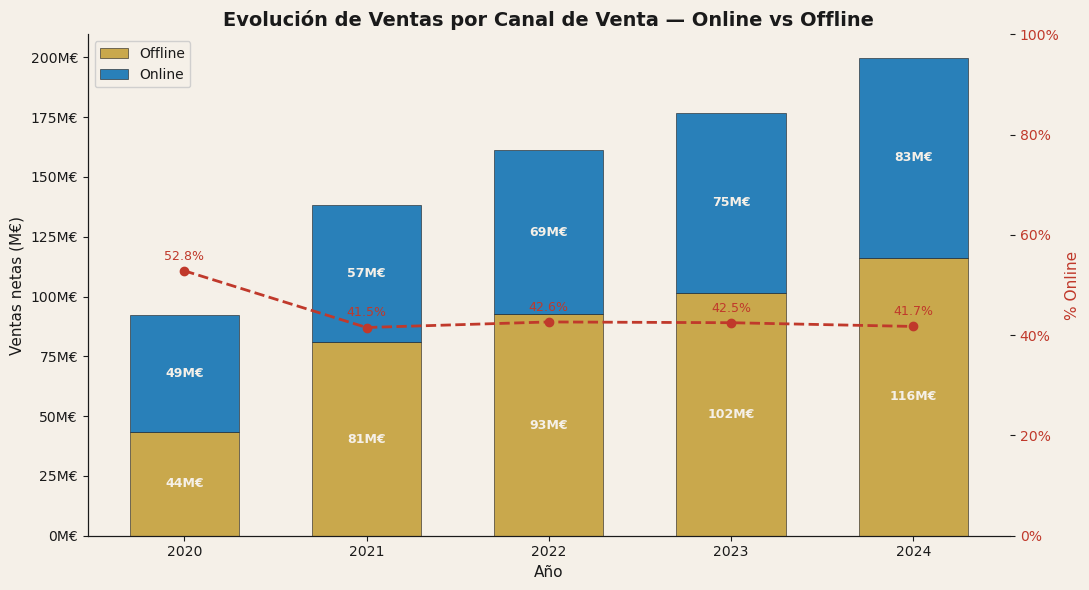

In [13]:
# ============================================================
# GRÁFICA C4 — Evolución Online vs Offline por año
# (La variable 'categoria' tiene un único valor en este dataset
#  sintético —'Ropa'— por lo que se sustituye por el canal de venta)
# ============================================================
ventas_lineas['anio'] = ventas_lineas['fecha_venta'].dt.year
canal_anio = (
    ventas_lineas
    .groupby(['anio', 'canal_venta'])['venta_neta_sin_iva_eur']
    .sum()
    .unstack(fill_value=0)
)
total_anio = canal_anio.sum(axis=1)
pct_online = canal_anio['Online'] / total_anio * 100

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(CREAM)

x = np.arange(len(canal_anio))
w = 0.38
canales_cols = canal_anio.columns.tolist()
canal_colors = [GOLD, BLUE_]

bottom = np.zeros(len(canal_anio))
for i, (canal, color) in enumerate(zip(canales_cols, canal_colors)):
    bars = ax.bar(canal_anio.index, canal_anio[canal] / 1e6,
                  bottom=bottom, color=color, edgecolor=BLACK,
                  linewidth=0.4, width=0.6, label=canal)
    for bar, val in zip(bars, canal_anio[canal].values):
        if val / 1e6 > 5:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f'{val/1e6:.0f}M€', ha='center', va='center',
                    fontsize=9, color=CREAM, fontweight='bold')
    bottom += canal_anio[canal].values / 1e6

# % Online como línea secundaria
ax2 = ax.twinx()
ax2.plot(canal_anio.index, pct_online.values, 'o--',
         color=RED_, linewidth=2, markersize=6, label='% Online')
ax2.set_ylabel('% Online', fontsize=11, color=RED_)
ax2.tick_params(axis='y', labelcolor=RED_)
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
for anio, pct in zip(canal_anio.index, pct_online.values):
    ax2.annotate(f'{pct:.1f}%', (anio, pct), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=9, color=RED_)

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Ventas netas (M€)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M€'))
ax.set_title('Evolución de Ventas por Canal de Venta — Online vs Offline',
             fontweight='bold', fontsize=14)
ax.legend(loc='upper left', framealpha=0.9)

plt.tight_layout()
guardar_img('eda_ventas_canal_anio', fig)
plt.show()

  → img/eda_distribucion_yt_v007.png


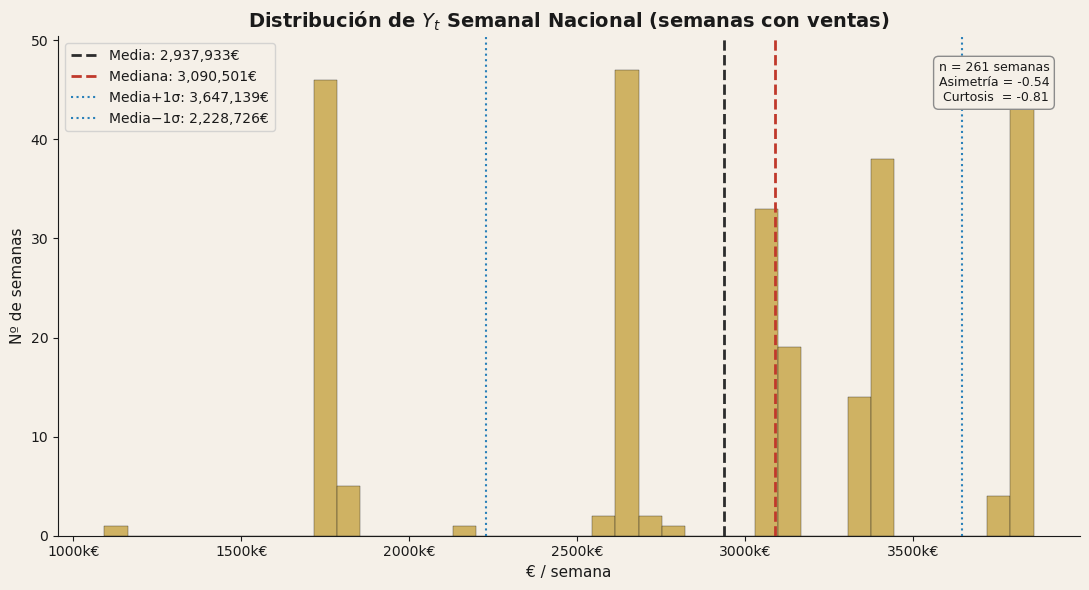

In [14]:
# ============================================================
# GRÁFICA C5 — Distribución del ticket (Yt semanal)
# ============================================================
yt_nz = df_ventas[df_ventas['Yt'] > 0]['Yt']

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(CREAM)

ax.hist(yt_nz, bins=40, color=GOLD, edgecolor=BLACK, linewidth=0.3, alpha=0.85)
ax.axvline(yt_nz.mean(),   color=DARK,  linestyle='--', linewidth=2,
           label=f'Media: {yt_nz.mean():,.0f}€')
ax.axvline(yt_nz.median(), color=RED_,  linestyle='--', linewidth=2,
           label=f'Mediana: {yt_nz.median():,.0f}€')
ax.axvline(yt_nz.mean() + yt_nz.std(), color=BLUE_, linestyle=':', linewidth=1.5,
           label=f'Media+1σ: {yt_nz.mean()+yt_nz.std():,.0f}€')
ax.axvline(yt_nz.mean() - yt_nz.std(), color=BLUE_, linestyle=':', linewidth=1.5,
           label=f'Media−1σ: {yt_nz.mean()-yt_nz.std():,.0f}€')

ax.set_title('Distribución de $Y_t$ Semanal Nacional (semanas con ventas)',
             fontweight='bold', fontsize=14)
ax.set_xlabel('€ / semana')
ax.set_ylabel('Nº de semanas')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k€'))
ax.legend()

stats_text = (
    f'n = {len(yt_nz)} semanas\n'
    f'Asimetría = {yt_nz.skew():.2f}\n'
    f'Curtosis  = {yt_nz.kurtosis():.2f}'
)
ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
        fontsize=9, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=CREAM, edgecolor=GRAY))

plt.tight_layout()
guardar_img('eda_distribucion_yt', fig)
plt.show()

---
## Bloque D — Inversión en Medios

  → img/eda_inversion_canal_v007.png


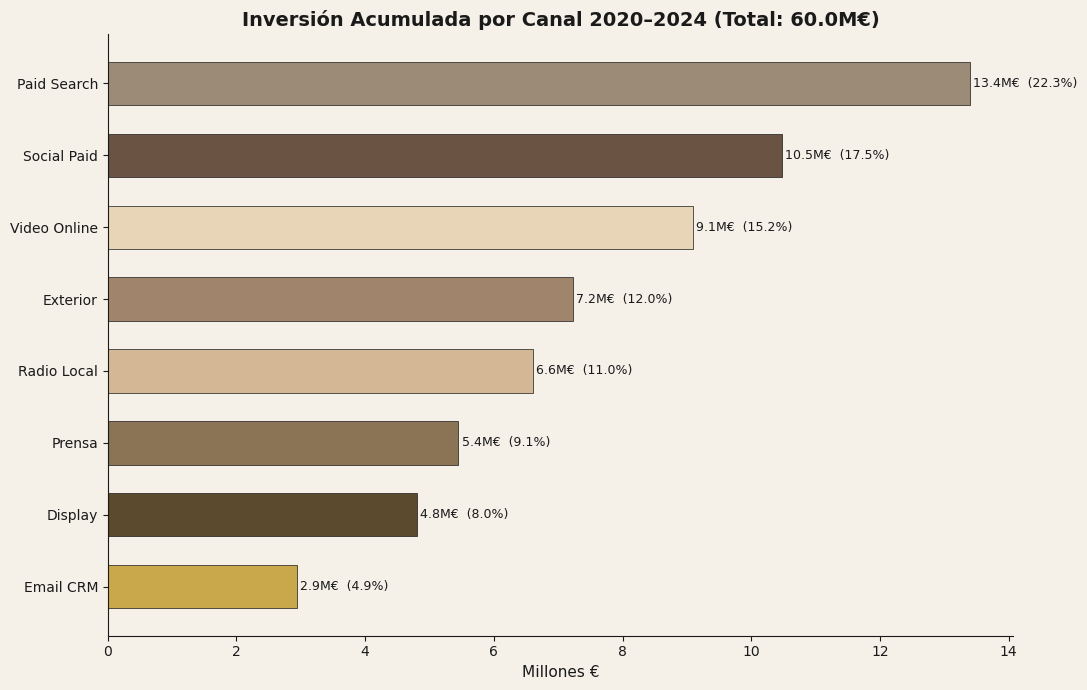

In [15]:
# ============================================================
# GRÁFICA D1 — Inversión acumulada por canal (barras)
# ============================================================
canales_cols = [c for c in df_inv.columns if c not in ['semana_dt', 'anio']]
inv_total_canal = df_inv[canales_cols].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(CREAM)

bars = ax.barh(inv_total_canal.index, inv_total_canal.values / 1e6,
               color=COLORS[:len(canales_cols)], edgecolor=BLACK, linewidth=0.5, height=0.6)
for bar, v in zip(bars, inv_total_canal.values):
    pct = v / inv_total_canal.sum() * 100
    ax.text(v / 1e6 + 0.05, bar.get_y() + bar.get_height()/2,
            f'{v/1e6:.1f}M€  ({pct:.1f}%)', va='center', fontsize=9)

ax.set_title(f'Inversión Acumulada por Canal 2020–2024 (Total: {inv_total_canal.sum()/1e6:.1f}M€)',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Millones €')

plt.tight_layout()
guardar_img('eda_inversion_canal', fig)
plt.show()

  → img/eda_inversion_stacked_v007.png


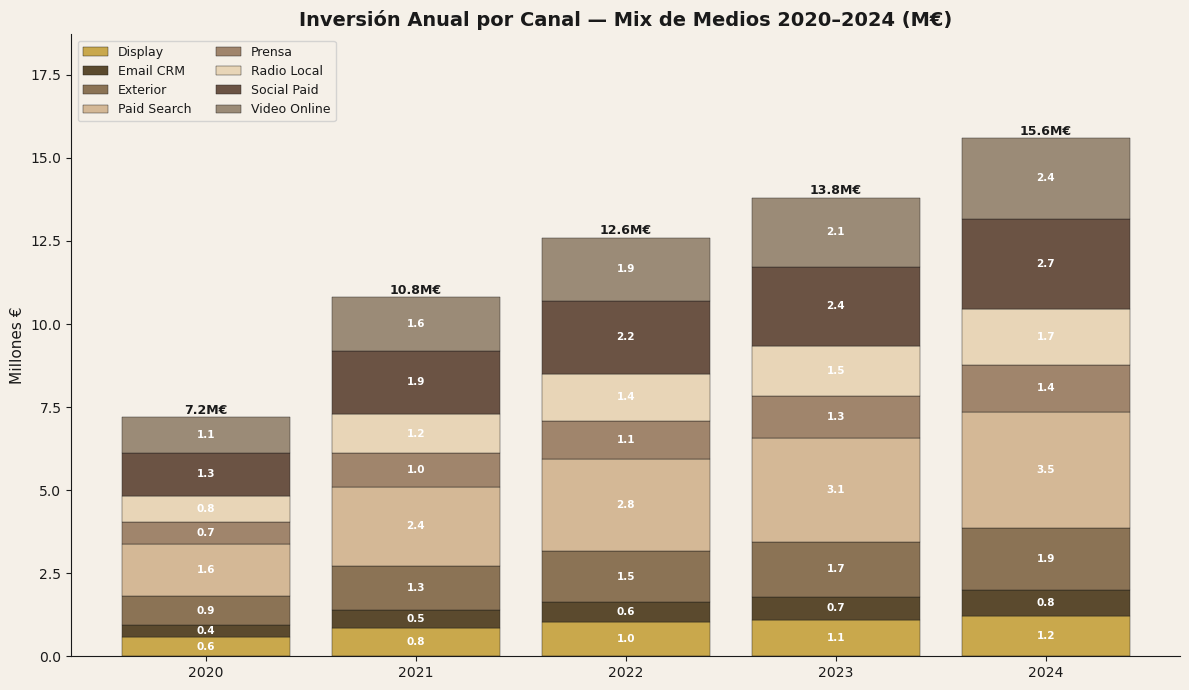

In [16]:
# ============================================================
# GRÁFICA D2 — Inversión anual por canal (barras apiladas)
# ============================================================
inv_anio_canal = df_inv.groupby('anio')[canales_cols].sum()

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(CREAM)

bottom = np.zeros(len(inv_anio_canal))
for i, canal in enumerate(canales_cols):
    vals = inv_anio_canal[canal].values / 1e6
    bars = ax.bar(inv_anio_canal.index, vals, bottom=bottom,
                  color=COLORS[i % len(COLORS)], edgecolor=BLACK,
                  linewidth=0.3, label=canal)
    # Etiqueta dentro de cada segmento si es suficientemente grande
    for j, (b, v) in enumerate(zip(bottom, vals)):
        if v > 0.3:
            ax.text(inv_anio_canal.index[j], b + v/2, f'{v:.1f}',
                    ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
    bottom += vals

# Total por año encima de cada barra
for i, (anio, total) in enumerate(inv_anio_canal.sum(axis=1).items()):
    ax.text(anio, total / 1e6 + 0.1, f'{total/1e6:.1f}M€',
            ha='center', fontsize=9, fontweight='bold')

ax.set_title('Inversión Anual por Canal — Mix de Medios 2020–2024 (M€)',
             fontweight='bold', fontsize=14)
ax.set_ylabel('Millones €')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.set_ylim(0, inv_anio_canal.sum(axis=1).max() / 1e6 * 1.2)

plt.tight_layout()
guardar_img('eda_inversion_stacked', fig)
plt.show()

  → img/eda_inversion_semanal_canal_v007.png


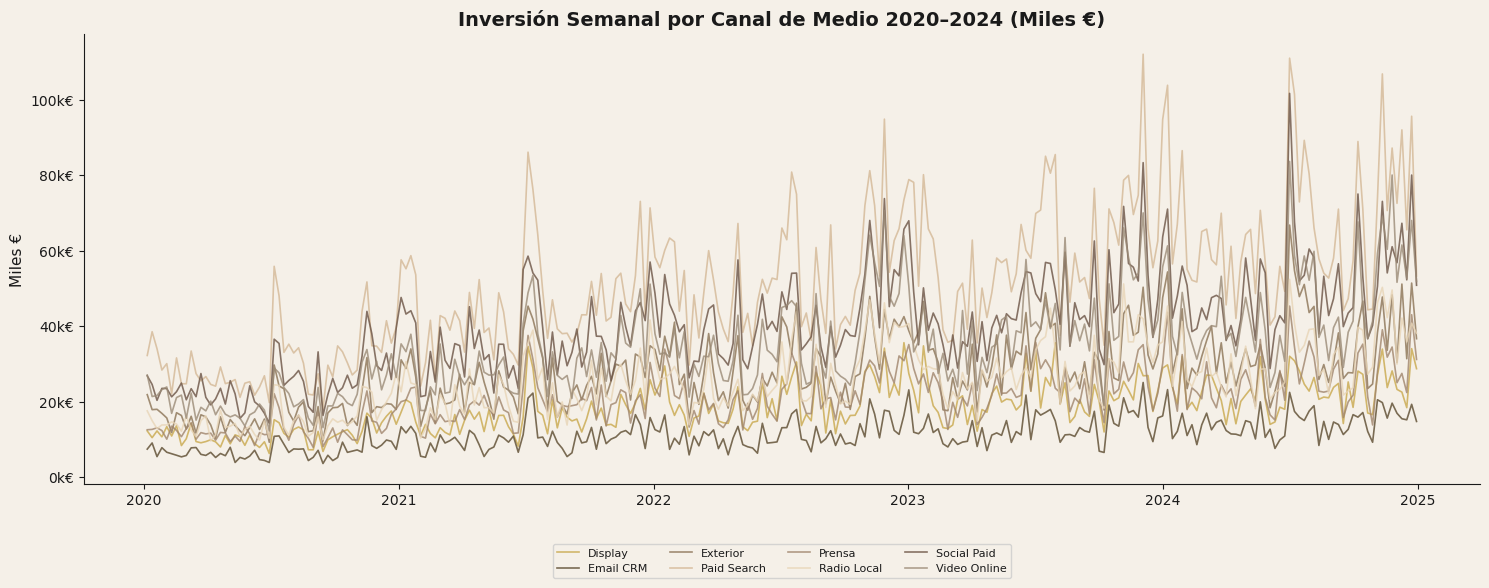

In [17]:
# ============================================================
# GRÁFICA D3 — Serie temporal de inversión semanal por canal
# ============================================================
fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor(CREAM)

for i, canal in enumerate(canales_cols):
    ax.plot(df_inv['semana_dt'], df_inv[canal] / 1e3,
            color=COLORS[i % len(COLORS)], linewidth=1.2,
            alpha=0.8, label=canal)

ax.set_title('Inversión Semanal por Canal de Medio 2020–2024 (Miles €)',
             fontweight='bold', fontsize=14)
ax.set_ylabel('Miles €')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))
ax.legend(fontsize=8, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.12))

plt.tight_layout()
guardar_img('eda_inversion_semanal_canal', fig)
plt.show()

  → img/eda_mix_inversion_heatmap_v007.png


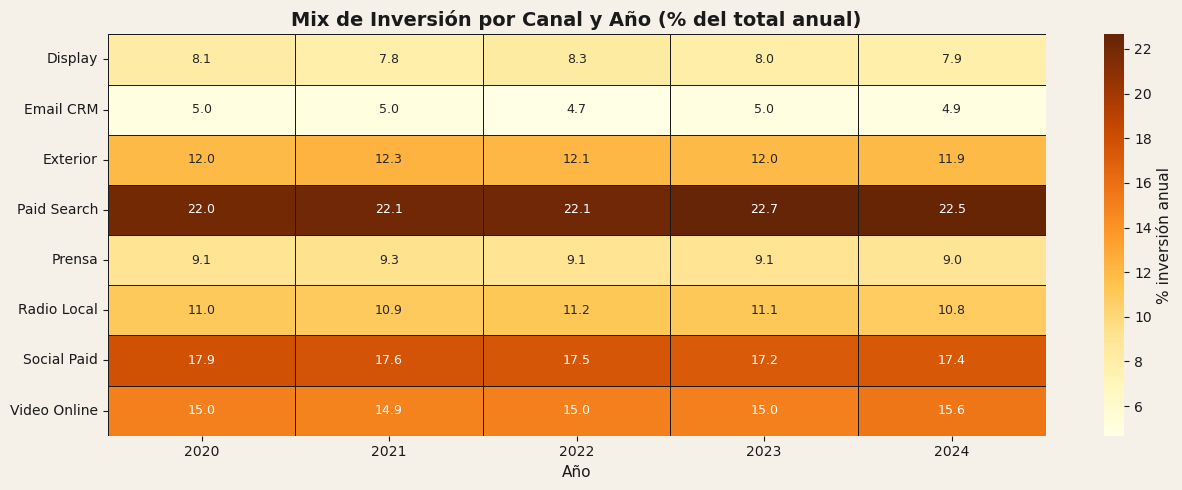

In [18]:
# ============================================================
# GRÁFICA D4 — Mix % de inversión por canal (heatmap año × canal)
# ============================================================
inv_mix_pct = inv_anio_canal.div(inv_anio_canal.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(CREAM)

sns.heatmap(
    inv_mix_pct.T, ax=ax,
    cmap='YlOrBr', annot=True, fmt='.1f',
    annot_kws={'size': 9}, linewidths=0.5, linecolor=BLACK,
    cbar_kws={'label': '% inversión anual'}
)
ax.set_title('Mix de Inversión por Canal y Año (% del total anual)',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Año')
ax.set_ylabel('')

plt.tight_layout()
guardar_img('eda_mix_inversion_heatmap', fig)
plt.show()

  → img/eda_scatter_inv_yt_v007.png


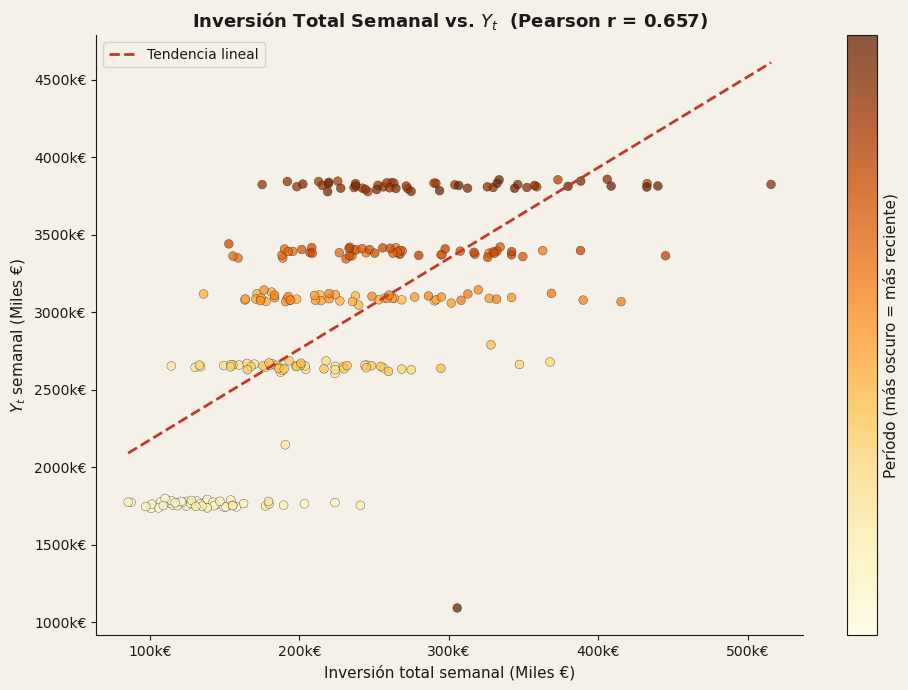

In [19]:
# ============================================================
# GRÁFICA D5 — Inversión total semanal vs Yt (scatter)
# ============================================================
inv_total_sem = df_inv[canales_cols].sum(axis=1)
# Alinear por semana_dt
df_merged = df_ventas[['semana_dt', 'Yt']].copy()
df_merged['inv_total'] = inv_total_sem.values

corr_inv_yt = df_merged['Yt'].corr(df_merged['inv_total'])

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(CREAM)

scatter = ax.scatter(
    df_merged['inv_total'] / 1e3, df_merged['Yt'] / 1e3,
    c=df_merged['semana_dt'].astype(np.int64),
    cmap='YlOrBr', alpha=0.75, s=40, edgecolors=BLACK, linewidths=0.3
)
# Línea de tendencia
z = np.polyfit(df_merged['inv_total'], df_merged['Yt'], 1)
x_range = np.linspace(df_merged['inv_total'].min(), df_merged['inv_total'].max(), 100)
ax.plot(x_range / 1e3, np.poly1d(z)(x_range) / 1e3,
        color=RED_, linewidth=2, linestyle='--', label=f'Tendencia lineal')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Período (más oscuro = más reciente)')
cbar.set_ticks([])

ax.set_title(f'Inversión Total Semanal vs. $Y_t$  (Pearson r = {corr_inv_yt:.3f})',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Inversión total semanal (Miles €)')
ax.set_ylabel('$Y_t$ semanal (Miles €)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))
ax.legend()

plt.tight_layout()
guardar_img('eda_scatter_inv_yt', fig)
plt.show()

---
## Bloque E — Diagnóstico de Privacidad (GDPR / iOS 14)

> **Nota:** los datos de degradación del tracking y evolución del CAC son **ilustrativos** (benchmarks de industria moda), no provienen directamente del dataset K-Moda. Se usan para contextualizar el problema que motiva el uso de MMM.

  → img/diagnostico_privacidad_tracking_v007.png


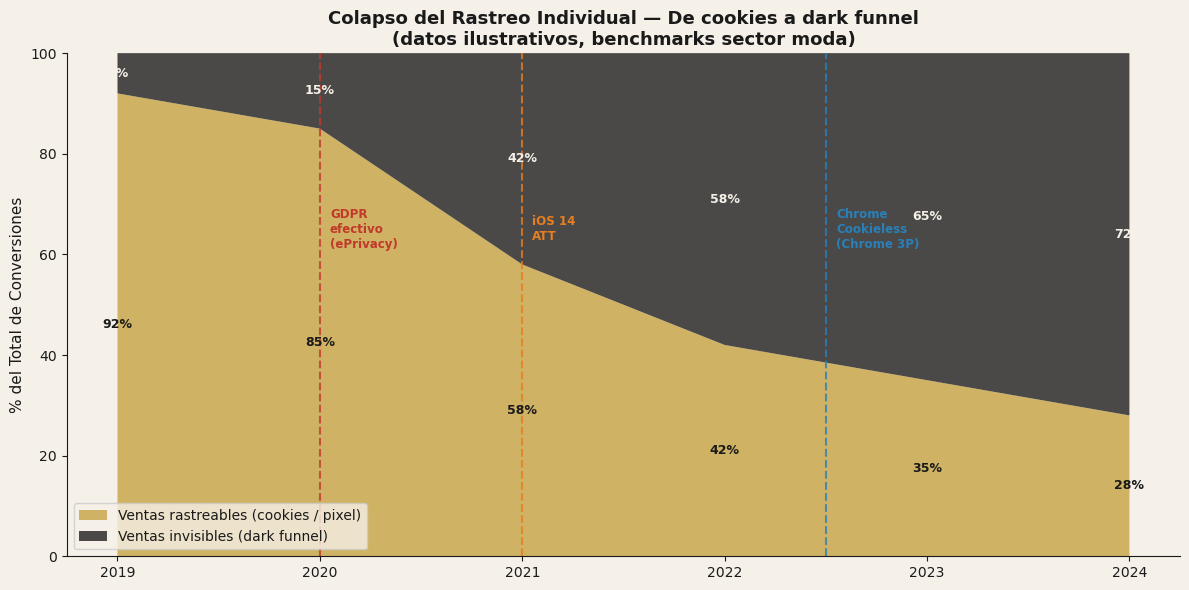

In [20]:
# ============================================================
# GRÁFICA E1 — Colapso del rastreo individual (tracking degradation)
# ============================================================
years = [2019, 2020, 2021, 2022, 2023, 2024]
tracking_rate = [92, 85, 58, 42, 35, 28]
dark_rate     = [8,  15, 42, 58, 65, 72]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(CREAM)

ax.stackplot(
    years, tracking_rate, dark_rate,
    labels=['Ventas rastreables (cookies / pixel)', 'Ventas invisibles (dark funnel)'],
    colors=[GOLD, DARK], alpha=0.85
)

# Eventos clave
ax.axvline(2020, color=RED_,    linestyle='--', alpha=0.8, linewidth=1.5)
ax.text(2020.05, 65, 'GDPR\nefectivo\n(ePrivacy)', fontsize=8.5, color=RED_,
        fontweight='bold', va='center')
ax.axvline(2021, color=ORANGE_, linestyle='--', alpha=0.8, linewidth=1.5)
ax.text(2021.05, 65, 'iOS 14\nATT', fontsize=8.5, color=ORANGE_,
        fontweight='bold', va='center')
ax.axvline(2022.5, color=BLUE_,   linestyle='--', alpha=0.8, linewidth=1.5)
ax.text(2022.55, 65, 'Chrome\nCookieless\n(Chrome 3P)', fontsize=8.5, color=BLUE_,
        fontweight='bold', va='center')

# Anotaciones de porcentaje
for yr, tr, dr in zip(years, tracking_rate, dark_rate):
    ax.text(yr, tr / 2, f'{tr}%', ha='center', va='center',
            fontsize=9, color=BLACK, fontweight='bold')
    ax.text(yr, tr + dr / 2, f'{dr}%', ha='center', va='center',
            fontsize=9, color=CREAM, fontweight='bold')

ax.set_title('Colapso del Rastreo Individual — De cookies a dark funnel\n'
             '(datos ilustrativos, benchmarks sector moda)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('% del Total de Conversiones')
ax.set_ylim(0, 100)
ax.set_xticks(years)
ax.legend(loc='lower left', fontsize=10)

plt.tight_layout()
guardar_img('diagnostico_privacidad_tracking', fig)
plt.show()

  → img/diagnostico_privacidad_cac_v007.png


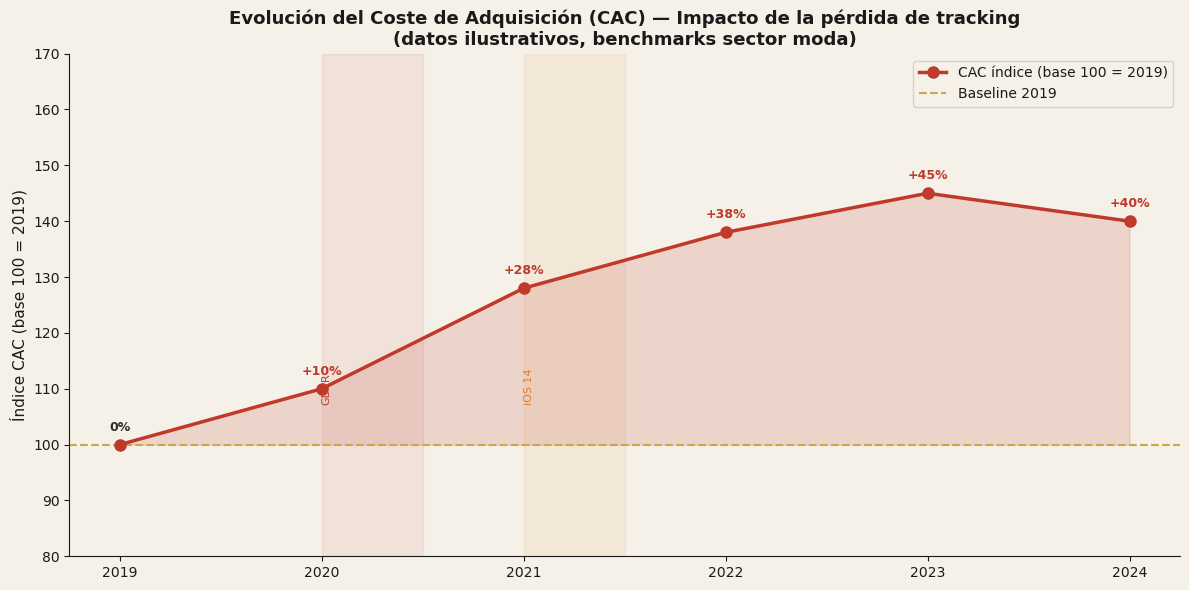

In [21]:
# ============================================================
# GRÁFICA E2 — Evolución del Coste de Adquisición (CAC)
# ============================================================
cac_index = [100, 110, 128, 138, 145, 140]  # base 100 = 2019

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(CREAM)

ax.plot(years, cac_index, color=RED_, linewidth=2.5,
        marker='o', markersize=8, zorder=3, label='CAC índice (base 100 = 2019)')
ax.fill_between(years, 100, cac_index,
                where=[c >= 100 for c in cac_index],
                alpha=0.15, color=RED_, zorder=2)
ax.axhline(100, color=GOLD, linestyle='--', linewidth=1.5, label='Baseline 2019')

for yr, val in zip(years, cac_index):
    delta = val - 100
    label_str = f'+{delta}%' if delta > 0 else '0%'
    ax.annotate(f'{label_str}', (yr, val),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9, fontweight='bold',
                color=RED_ if delta > 0 else DARK)

# Bandas de eventos
ax.axvspan(2020, 2020.5, alpha=0.08, color=RED_)
ax.axvspan(2021, 2021.5, alpha=0.08, color=ORANGE_)
ax.text(2020.0, 107, 'GDPR', fontsize=8, color=RED_, rotation=90, va='bottom')
ax.text(2021.0, 107, 'iOS 14', fontsize=8, color=ORANGE_, rotation=90, va='bottom')

ax.set_title('Evolución del Coste de Adquisición (CAC) — Impacto de la pérdida de tracking\n'
             '(datos ilustrativos, benchmarks sector moda)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Índice CAC (base 100 = 2019)')
ax.set_ylim(80, 170)
ax.set_xticks(years)
ax.legend()

plt.tight_layout()
guardar_img('diagnostico_privacidad_cac', fig)
plt.show()

  → img/diagnostico_privacidad_ecom_v007.png


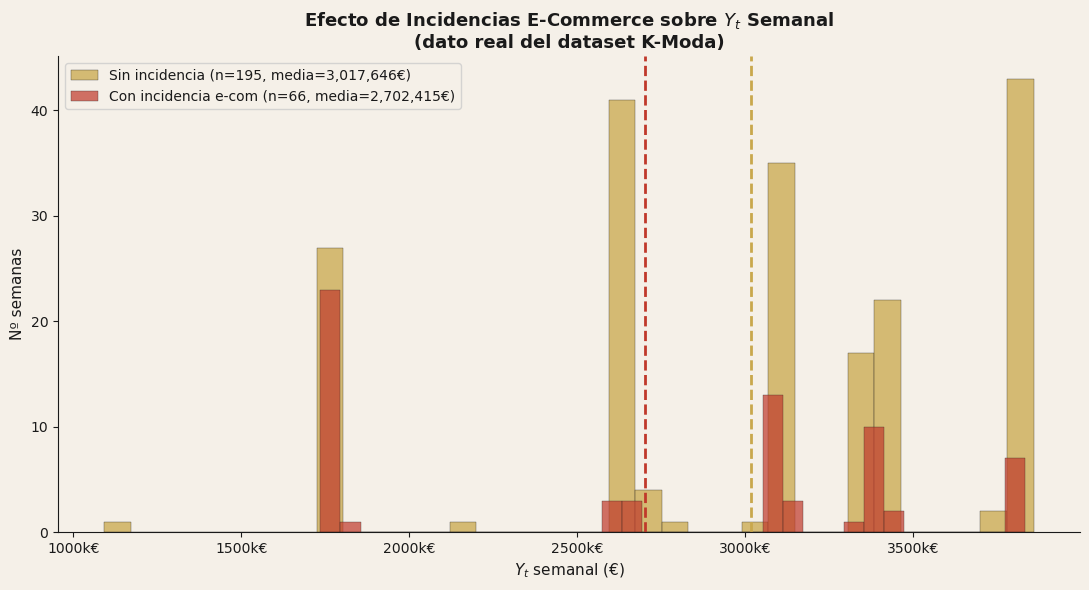

In [22]:
# ============================================================
# GRÁFICA E3 — Incidencia ecommerce sobre Yt (flag real del dataset)
# ============================================================
# Este sí es dato real: el flag incidencia_ecommerce en el calendario
yt_con_incidencia    = df_ventas[df_ventas['incidencia_ecommerce_flag'] == 1]['Yt']
yt_sin_incidencia    = df_ventas[df_ventas['incidencia_ecommerce_flag'] == 0]['Yt']

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(CREAM)

ax.hist(yt_sin_incidencia, bins=35, color=GOLD,  alpha=0.75,
        edgecolor=BLACK, linewidth=0.3,
        label=f'Sin incidencia (n={len(yt_sin_incidencia)}, media={yt_sin_incidencia.mean():,.0f}€)')
ax.hist(yt_con_incidencia, bins=35, color=RED_,  alpha=0.70,
        edgecolor=BLACK, linewidth=0.3,
        label=f'Con incidencia e-com (n={len(yt_con_incidencia)}, media={yt_con_incidencia.mean():,.0f}€)')

ax.axvline(yt_sin_incidencia.mean(), color=GOLD, linewidth=2, linestyle='--')
ax.axvline(yt_con_incidencia.mean(), color=RED_,  linewidth=2, linestyle='--')

ax.set_title('Efecto de Incidencias E-Commerce sobre $Y_t$ Semanal\n'
             '(dato real del dataset K-Moda)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('$Y_t$ semanal (€)')
ax.set_ylabel('Nº semanas')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k€'))
ax.legend()

plt.tight_layout()
guardar_img('diagnostico_privacidad_ecom', fig)
plt.show()

---
## Bloque F — Correlaciones Preliminares Adstock × Ventas

Calculamos un adstock simplificado con los parámetros del CLAUDE.md para obtener correlaciones Pearson antes del modelado completo (Fase 3).

In [23]:
# ============================================================
# CÁLCULO PRELIMINAR DE ADSTOCK (para correlaciones EDA)
# ============================================================
# Parámetros lag (semanas) y alpha según CLAUDE.md
PARAMS = {
    'Paid Search' : {'lag': 0, 'alpha': 0.45},
    'Social Paid' : {'lag': 1, 'alpha': 0.6},
    'Video Online': {'lag': 1, 'alpha': 0.7},
    'Display'     : {'lag': 0, 'alpha': 0.40},
    'Email CRM'   : {'lag': 0, 'alpha': 0.15},
    'Radio Local' : {'lag': 1, 'alpha': 0.50},
    'Exterior'    : {'lag': 1, 'alpha': 0.6},
    'Prensa'      : {'lag': 1, 'alpha': 0.25},
}

def apply_lag_adstock(series, lag, alpha):
    """Aplica lag temporal y adstock geométrico."""
    x_lag = series.shift(lag).fillna(0).values
    adstock = np.zeros(len(x_lag))
    adstock[0] = x_lag[0]
    for t in range(1, len(x_lag)):
        adstock[t] = x_lag[t] + alpha * adstock[t - 1]
    return adstock

# Construir dataframe con adstocks para los canales disponibles en df_inv
df_adstock = df_ventas[['semana_dt', 'Yt']].copy()

canales_disponibles = [c for c in PARAMS.keys() if c in df_inv.columns]
for canal in canales_disponibles:
    p = PARAMS[canal]
    serie_inv = df_inv[canal].values
    adstock_vals = apply_lag_adstock(pd.Series(serie_inv), p['lag'], p['alpha'])
    df_adstock[f'adstock_{canal}'] = adstock_vals

# Correlaciones Pearson
adstock_cols = [f'adstock_{c}' for c in canales_disponibles]
corr_pearson = df_adstock[['Yt'] + adstock_cols].corr()['Yt'].drop('Yt')
corr_pearson.index = [c.replace('adstock_','') for c in corr_pearson.index]
corr_pearson = corr_pearson.sort_values(ascending=False)

print('CORRELACIONES PEARSON: Adstock × Yt semanal')
print('=' * 45)
for canal, r in corr_pearson.items():
    bar_chr = '█' * int(abs(r) * 30)
    print(f'  {canal:<16}: r = {r:+.4f}  {bar_chr}')
print()
print(f'  Canal con mayor correlación: {corr_pearson.idxmax()} (r={corr_pearson.max():.4f})')

CORRELACIONES PEARSON: Adstock × Yt semanal
  Social Paid     : r = +0.7800  ███████████████████████
  Video Online    : r = +0.7798  ███████████████████████
  Exterior        : r = +0.7516  ██████████████████████
  Paid Search     : r = +0.7500  ██████████████████████
  Radio Local     : r = +0.7258  █████████████████████
  Display         : r = +0.7200  █████████████████████
  Prensa          : r = +0.6761  ████████████████████
  Email CRM       : r = +0.6260  ██████████████████

  Canal con mayor correlación: Social Paid (r=0.7800)


  → img/correlaciones_adstock_v027.png


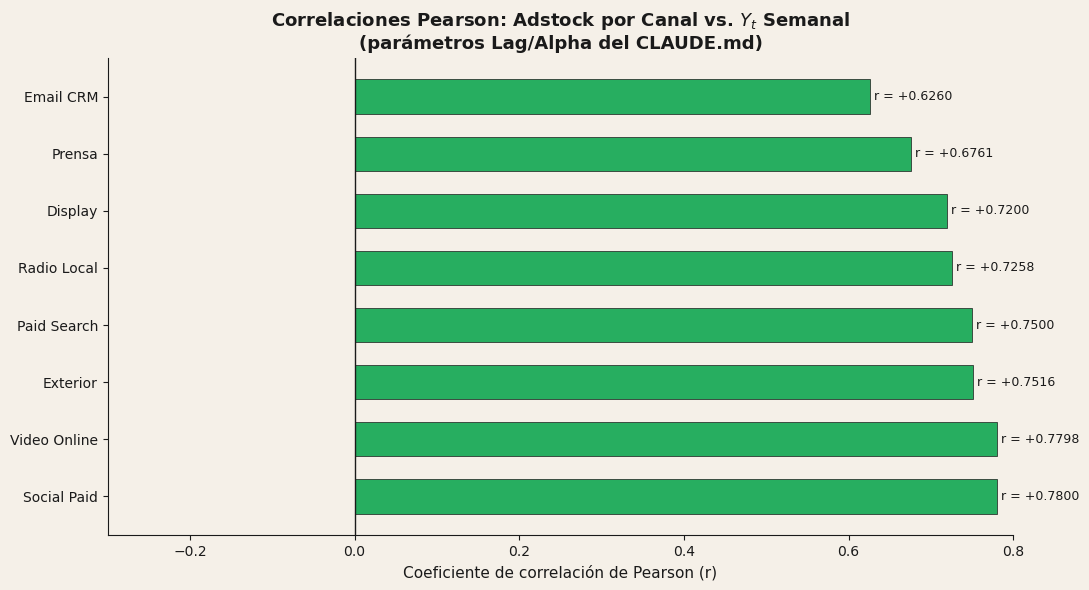

In [24]:
# ============================================================
# GRÁFICA F1 — Correlaciones Pearson Adstock × Yt
# ============================================================
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(CREAM)

colores_corr = [GREEN_ if r > 0 else RED_ for r in corr_pearson.values]
bars = ax.barh(corr_pearson.index, corr_pearson.values,
               color=colores_corr, edgecolor=BLACK, linewidth=0.5, height=0.6)

for bar, r in zip(bars, corr_pearson.values):
    x_pos = r + 0.005 if r >= 0 else r - 0.005
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'r = {r:+.4f}', va='center',
            ha='left' if r >= 0 else 'right', fontsize=9)

ax.axvline(0, color=BLACK, linewidth=1)
ax.set_title('Correlaciones Pearson: Adstock por Canal vs. $Y_t$ Semanal\n'
             '(parámetros Lag/Alpha del CLAUDE.md)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Coeficiente de correlación de Pearson (r)')
ax.set_xlim(-0.3, 0.8)

plt.tight_layout()
guardar_img('correlaciones_adstock', fig)
plt.show()

  → img/eda_matriz_correlaciones_v007.png


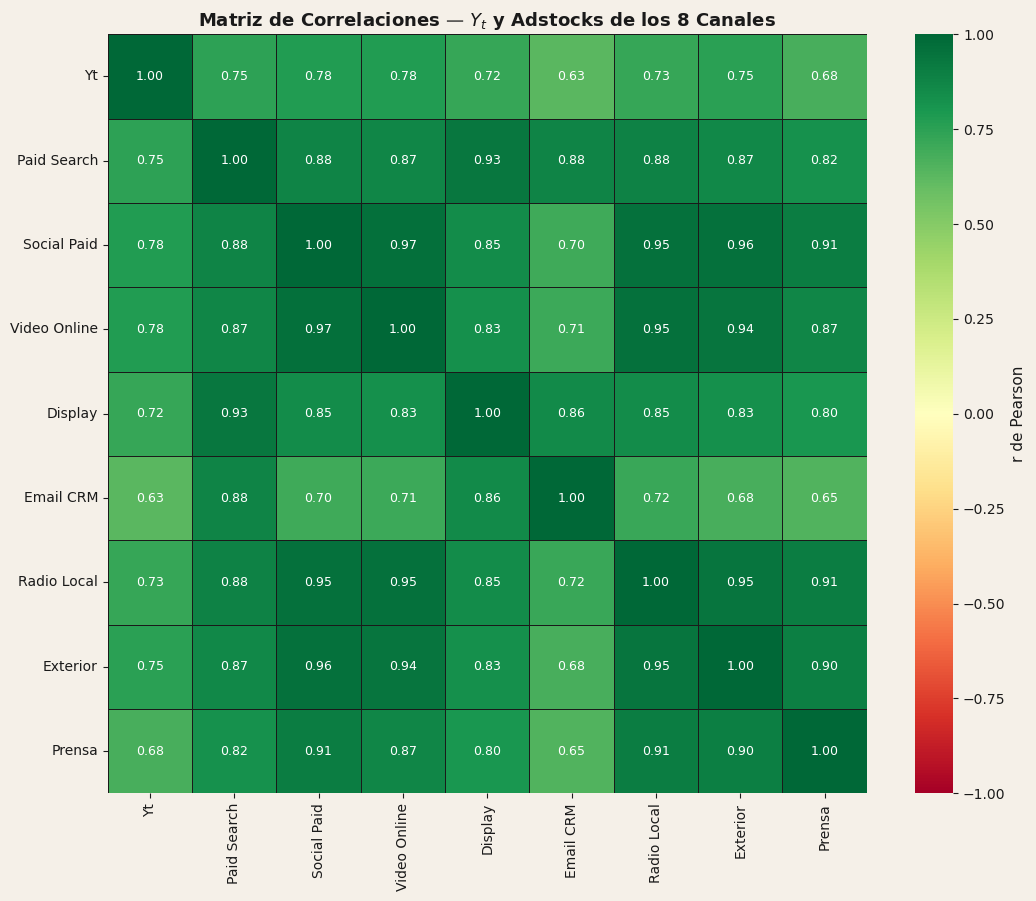

In [25]:
# ============================================================
# GRÁFICA F2 — Heatmap de correlaciones completo
# ============================================================
corr_matrix = df_adstock[['Yt'] + adstock_cols].corr()
corr_matrix.columns = ['Yt'] + canales_disponibles
corr_matrix.index   = ['Yt'] + canales_disponibles

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor(CREAM)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, ax=ax,
    cmap='RdYlGn', vmin=-1, vmax=1,
    annot=True, fmt='.2f',
    annot_kws={'size': 9},
    linewidths=0.5, linecolor=BLACK,
    square=True,
    cbar_kws={'label': 'r de Pearson'}
)
ax.set_title('Matriz de Correlaciones — $Y_t$ y Adstocks de los 8 Canales',
             fontweight='bold', fontsize=13)

plt.tight_layout()
guardar_img('eda_matriz_correlaciones', fig)
plt.show()

  → img/eda_adstock_vs_yt_social_paid_v004.png


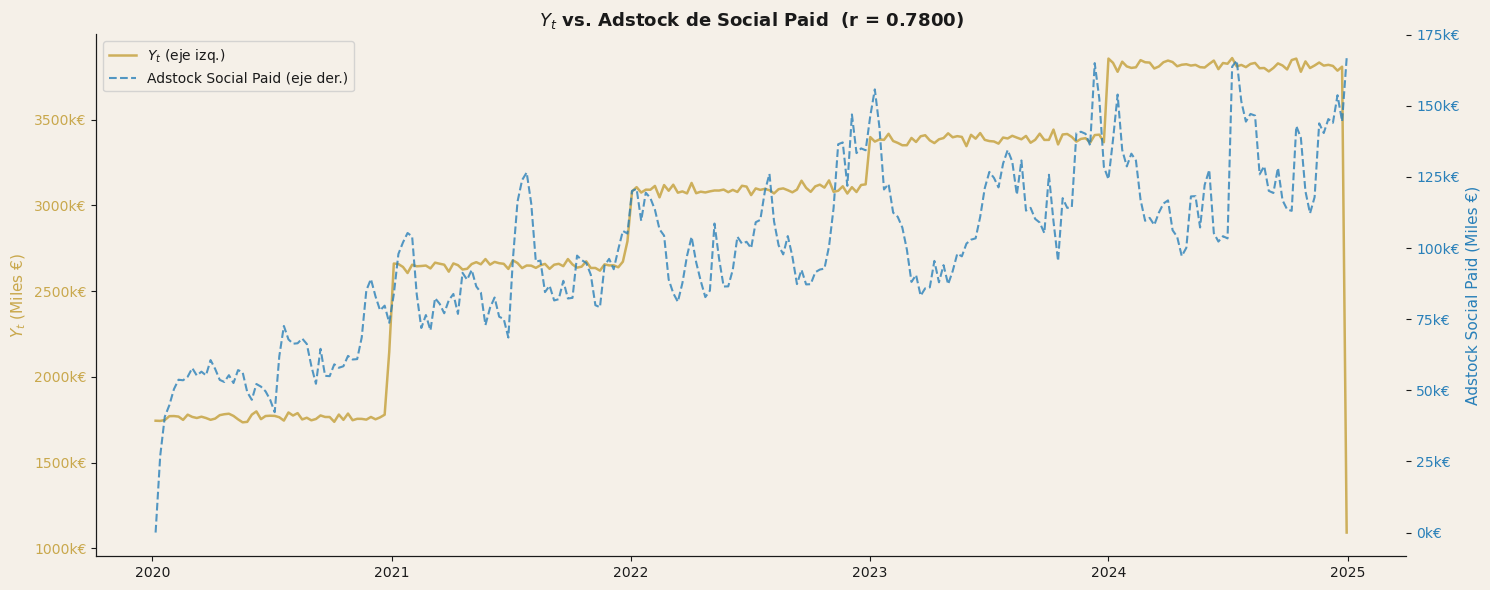

In [26]:
# ============================================================
# GRÁFICA F3 — Adstock del canal más correlado vs Yt
# ============================================================
best_canal = corr_pearson.idxmax()
best_adstock_col = f'adstock_{best_canal}'

fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor(CREAM)

ax2 = ax.twinx()

ax.plot(df_adstock['semana_dt'], df_adstock['Yt'] / 1e3,
        color=GOLD, linewidth=1.8, alpha=0.9, label=f'$Y_t$ (eje izq.)')
ax2.plot(df_adstock['semana_dt'], df_adstock[best_adstock_col] / 1e3,
         color=BLUE_, linewidth=1.5, alpha=0.8, linestyle='--',
         label=f'Adstock {best_canal} (eje der.)')

ax.set_title(f'$Y_t$ vs. Adstock de {best_canal}  (r = {corr_pearson[best_canal]:.4f})',
             fontweight='bold', fontsize=13)
ax.set_ylabel('$Y_t$ (Miles €)', color=GOLD)
ax2.set_ylabel(f'Adstock {best_canal} (Miles €)', color=BLUE_)
ax.tick_params(axis='y', labelcolor=GOLD)
ax2.tick_params(axis='y', labelcolor=BLUE_)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
guardar_img(f'eda_adstock_vs_yt_{best_canal.lower().replace(" ","_")}', fig)
plt.show()

In [27]:
# ============================================================
# RESUMEN FINAL — FASE 2 EDA
# ============================================================
print('=' * 60)
print('  RESUMEN — FASE 2 EDA COMPLETADA')
print('=' * 60)

imgs_generadas = [f for f in os.listdir(IMG_DIR) if f.endswith('.png')]
nuevas = sorted([f for f in imgs_generadas
                 if any(f.startswith(p) for p in [
                     'serie_temporal', 'eda_', 'diagnostico_', 'correlaciones_'
                 ])])
print(f'\n  Gráficas generadas en esta fase: {len(nuevas)}')
for img in nuevas:
    print(f'    • {img}')

print('\n  Correlaciones Pearson Adstock × Yt:')
for canal, r in corr_pearson.items():
    print(f'    {canal:<16}: r = {r:+.4f}')

print(f'\n  Canal con mayor correlación con Yt: {corr_pearson.idxmax()} (r={corr_pearson.max():.4f})')
print(f'  Total ventas 2020-2024            : {ventas_lineas["venta_neta_sin_iva_eur"].sum()/1e6:.2f}M€')
print(f'  Total inversión 2020-2024         : {df_inv[canales_cols].sum().sum()/1e6:.2f}M€')
print(f'  Semanas analizadas                : {len(df_ventas)}')
print('\n  ✓ FASE 2 COMPLETADA — Lista para Fase 3 (Feature Engineering)')
print('=' * 60)

  RESUMEN — FASE 2 EDA COMPLETADA

  Gráficas generadas en esta fase: 76
    • correlaciones_adstock_v021.png
    • correlaciones_adstock_v022.png
    • correlaciones_adstock_v023.png
    • correlaciones_adstock_v024.png
    • correlaciones_adstock_v025.png
    • correlaciones_adstock_v026.png
    • correlaciones_adstock_v027.png
    • diagnostico_privacidad_cac_v005.png
    • diagnostico_privacidad_cac_v006.png
    • diagnostico_privacidad_cac_v007.png
    • diagnostico_privacidad_ecom_v005.png
    • diagnostico_privacidad_ecom_v006.png
    • diagnostico_privacidad_ecom_v007.png
    • diagnostico_privacidad_tracking_v005.png
    • diagnostico_privacidad_tracking_v006.png
    • diagnostico_privacidad_tracking_v007.png
    • eda_adstock_vs_yt_exterior_v003.png
    • eda_adstock_vs_yt_social_paid_v002.png
    • eda_adstock_vs_yt_social_paid_v003.png
    • eda_adstock_vs_yt_social_paid_v004.png
    • eda_cuota_ciudad_v005.png
    • eda_cuota_ciudad_v006.png
    • eda_cuota_ciudad_v007.png

---
## Outputs de la Fase 2

| Imagen | Bloque | Uso en notebook ejecutivo |
|--------|--------|---------------------------|
| `serie_temporal_ventas_v*.png` | A | Sección 2 — Señal de valor |
| `eda_ventas_mensuales_v*.png` | A | Sección 2 |
| `eda_ventas_anuales_v*.png` | A | Sección 0 / Resumen |
| `eda_estacionalidad_mensual_v*.png` | B | Sección 3 — Variables exógenas |
| `eda_heatmap_estacional_v*.png` | B | Sección 3 |
| `eda_estacionalidad_dow_v*.png` | B | Sección 3 |
| `eda_efecto_calendario_v*.png` | B | Sección 3 |
| `eda_ventas_ciudad_v*.png` | C | Sección 2 |
| `eda_cuota_ciudad_v*.png` | C | Sección 2 |
| `eda_ventas_canal_venta_v*.png` | C | Sección 2 |
| `eda_ventas_categoria_v*.png` | C | Sección 2 |
| `eda_distribucion_yt_v*.png` | C | Sección 3 |
| `eda_inversion_canal_v*.png` | D | Sección 4 — Pesos óptimos |
| `eda_inversion_stacked_v*.png` | D | Sección 4 |
| `eda_inversion_semanal_canal_v*.png` | D | Sección 3 |
| `eda_mix_inversion_heatmap_v*.png` | D | Sección 4 |
| `eda_scatter_inv_yt_v*.png` | D | Sección 3 |
| `diagnostico_privacidad_tracking_v*.png` | E | Sección 1 — Privacidad |
| `diagnostico_privacidad_cac_v*.png` | E | Sección 1 |
| `diagnostico_privacidad_ecom_v*.png` | E | Sección 1 |
| `correlaciones_adstock_v*.png` | F | Sección 3 |
| `eda_matriz_correlaciones_v*.png` | F | Sección 3 |
| `eda_adstock_vs_yt_*_v*.png` | F | Sección 3 |